<center><h1>A notebook for preparing the data for classification</h1></center>

# Imports

All necessary imports for preparing the data and constructing the datasets

In [1]:
import numpy as np

import torch
from torch.utils.data import Dataset, ConcatDataset

from torchvision.transforms import functional

import plotly
import plotly.express as px

import matplotlib.pyplot as plt

import sharpnesses as sh

import helper

# Constants

A special value used to display the images to the right and to the left from the focused one

In [2]:
GAP = 50

# Dataset class

A main class for defining the dataset
It takes as the input an image stack, an index of the in-focus sample, number of steps (general range), acceptable range, angle and rotation flag

Apparently, it takes values of $f$, $N$, and $n$

It returns dataset with labelled classes, as defined in the main paper

In [3]:
class ClassificationDataset(Dataset):
    def __init__(self, stack, focused, steps, acceptable, angle=45, rotation=True, transform=None):
        self.stack = stack
        self.focused = focused
        self.steps = steps
        self.angle = angle
        self.acceptable = acceptable
        self.rotation = rotation

        self.focal_range = self.find_range()

        if self.rotation:
            self.rotations = self.create_rotation()
            self.data = self.rotations
        else:
            self.data = self.focal_range

        self.labels = self.assign_labels()
        self.transform = transform

    # A method to compute labels
    def get_labels(self):
        labels = {}
        for l in range(len(self.focal_range)):
            if self.steps - self.acceptable <= l <= self.steps + self.acceptable:
                labels[l] = 0
            elif l < self.steps - self.acceptable:
                labels[l] = np.abs(self.steps - self.acceptable - l)
            elif l > self.steps + self.acceptable:
                labels[l] = np.abs(self.steps + self.acceptable - l)
        return labels

    # A method to define a range
    def find_range(self):
        return self.stack[self.focused - self.steps : self.focused + self.steps + 1]

    # A method to assign labels to images
    def assign_labels(self):
        labels = self.get_labels()
        if self.rotation:
            return np.array(list(labels.values()) * (360 // self.angle))
        else:
            return np.array(list(labels.values()))

    # A method used to create rotations
    def create_rotation(self):
        rotations = []
        num_rotations = 360 // self.angle
        tensor = torch.from_numpy(self.focal_range)

        for n in range(1, num_rotations + 1):
            rotated_tensor = functional.rotate(tensor, n * self.angle)
            rotations.append(rotated_tensor.numpy())

        return np.concatenate(rotations)

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        image, label = self.data[idx], self.labels[idx]

        if self.transform:
            image = self.transform(image)

        return image, label

# Functions

These values are defined for plotting the sharpness graphs of the given stack

Here, we import the implemented functions for sharpness calculations from the self-written module sharpnesses

In [4]:
funcs = [np.sum, sh.gradient_sharpness, sh.sobel_sharpness, sh.laplacian_sharpness, sh.canny_sharpness]
names = ['sum', 'gradient', 'sobel', 'laplacian', 'canny']
colours = ['y', 'r', 'g', 'm', 'c']

A special function to plot sharpness graphs for the given list of stacks

In [5]:
def plot_sharpness(stacks, name=None, save=False):
    num_funcs = len(funcs)
    num_stacks = len(stacks)

    fig, ax = plt.subplots(num_funcs, num_stacks, figsize=(12, 8), sharex='col')

    if num_stacks == 1:
        ax = np.expand_dims(ax, axis=1)

    for j, stack in enumerate(stacks):
        sharpness = np.empty((num_funcs, len(stack)), dtype=np.float32)

        for i in range(num_funcs):
            for k in range(len(stack)):
                sharpness[i][k] = funcs[i](stack[k])

        for l in range(num_funcs):
            ax[l, j].plot(sharpness[l], color=colours[l], label=names[l])
            ax[l, j].set_title(f'stack {j}, peak: {np.argmax(sharpness[l])}')
            ax[l, j].legend(loc='upper right')

    plt.tight_layout()

    if save:
        plt.savefig(f'figures/{name}_sharpness.png')

    plt.show()


A function to plot a single image from the stack

In [6]:
def plot_single(image, name):
    plt.imshow(image, cmap="gray")
    plt.tight_layout()
    plt.axis('off')
    plt.savefig(f"figures/{name}.png", bbox_inches='tight')
    plt.show()

# Data

In this section we look through stacks and determine the image in-focus

The stacks are stored in the special folder called data

For every stack we plot sharpness graphs and looking for peak

Then, using the plotly library we scroll through stack to find the needed image

Eventually, we create a dataset using the class defined above

In the very and using the helper module, we save the concatenated dataset to files


## looking for focused images (10x)

In [7]:
dataset_10x_0 = np.load('data/10x_0.npy')
dataset_10x_1 = np.load('data/10x_1.npy')

stacks_10x = [dataset_10x_0, dataset_10x_1]

In [8]:
print(dataset_10x_0.shape, dataset_10x_1.shape)

(3001, 300, 300) (4001, 300, 300)


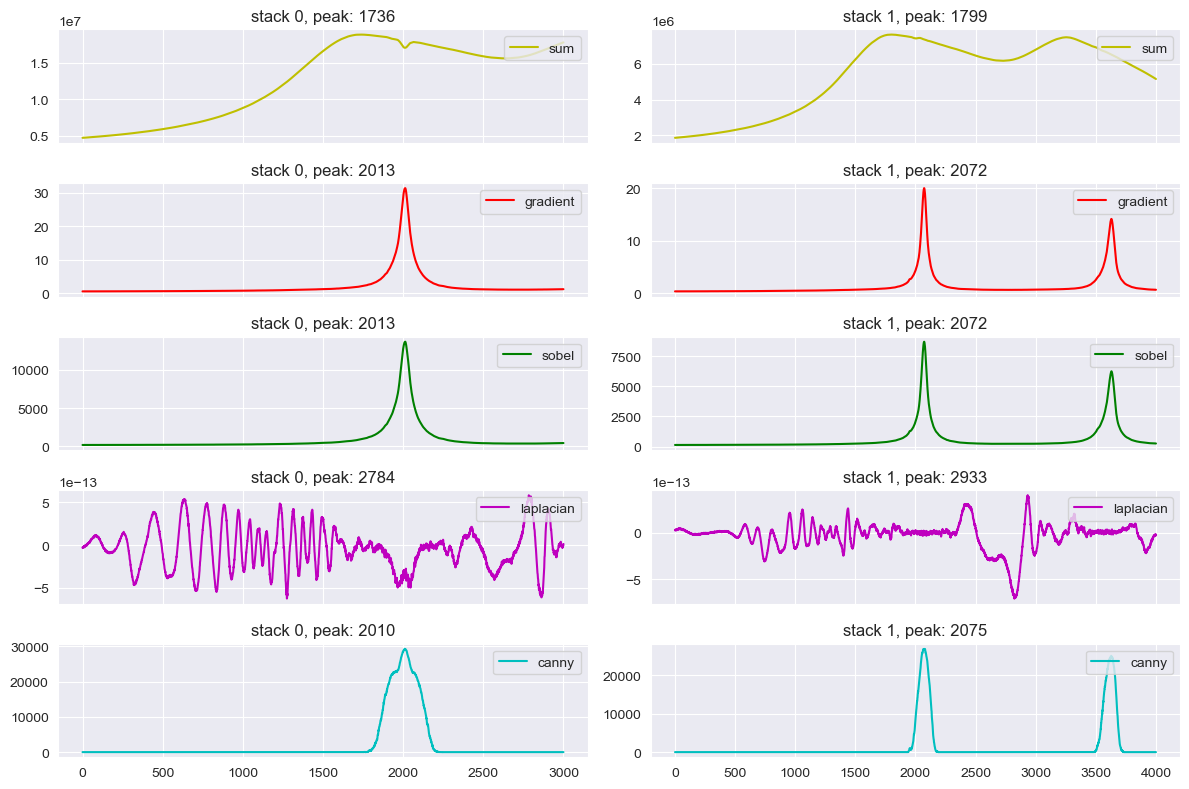

In [9]:
plot_sharpness(stacks_10x)

### stack 0

In [11]:
torch_10x_0 = ClassificationDataset(dataset_10x_0, focused=2013, acceptable=7, steps=100)

In [12]:
len(torch_10x_0)

1608

### stack 1

In [13]:
fig = px.imshow(dataset_10x_1[2072 - GAP : 2072 + GAP], animation_frame=0, binary_string=True)
# plotly.io.show(fig)

In [14]:
torch_10x_1 = ClassificationDataset(dataset_10x_1, focused=2072, acceptable=7, steps=100)

## looking for focused images (20x)

In [15]:
dataset_20x_0 = np.load('data/20x_0.npy')

stacks_20x = [dataset_20x_0]

In [16]:
print(dataset_20x_0.shape)

(3751, 300, 300)


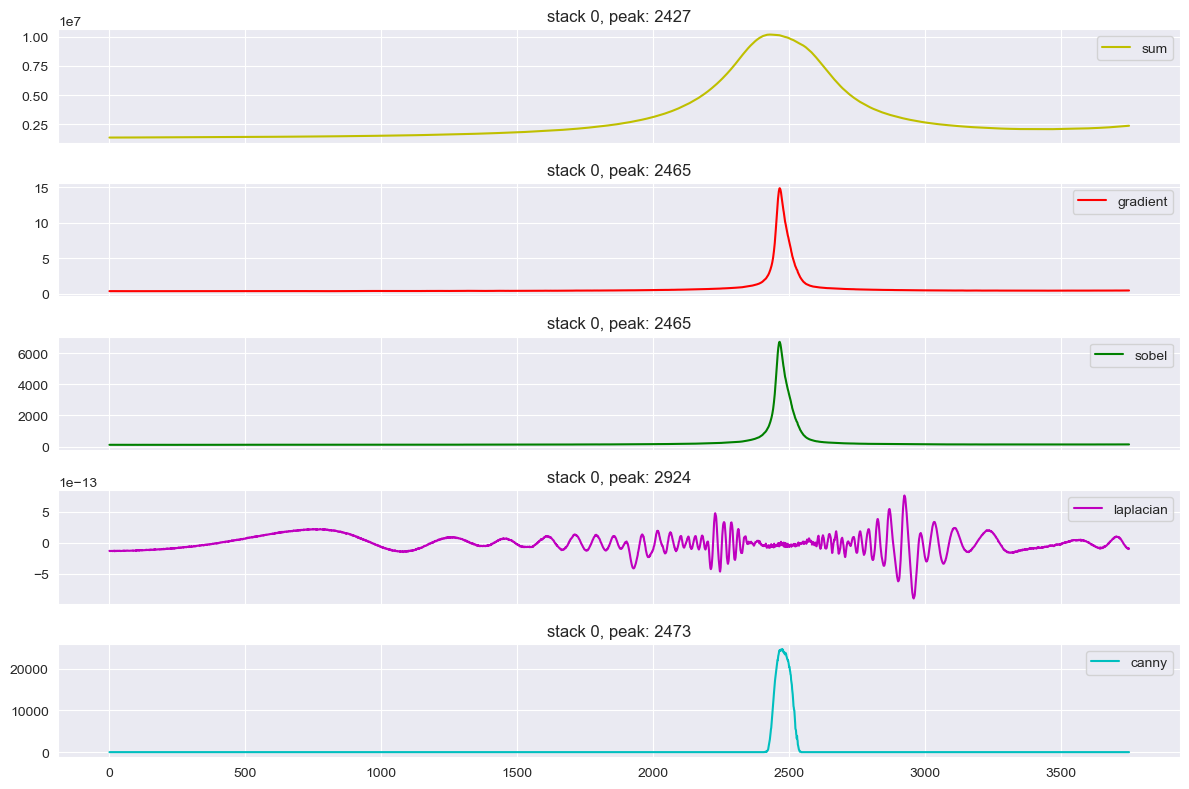

In [17]:
plot_sharpness(stacks_20x, save=True, name="20x")

### stack 0

In [18]:
fig = px.imshow(dataset_20x_0[2465 - GAP : 2465 + GAP], animation_frame=0, binary_string=True)
# plotly.io.show(fig)

In [19]:
torch_20x_0 = ClassificationDataset(dataset_20x_0, focused=2465, acceptable=5, steps=100)

## looking for focused images (40x)

In [20]:
dataset_40x_0 = np.load('data/40x_0.npy')
dataset_40x_1 = np.load('data/40x_1.npy')
dataset_40x_2 = np.load('data/40x_2.npy')
dataset_40x_3 = np.load('data/40x_3.npy')
dataset_40x_4 = np.load('data/40x_4.npy')
dataset_40x_5 = np.load('data/40x_5.npy')

stacks_40x = [dataset_40x_0, dataset_40x_1, dataset_40x_2, dataset_40x_3, dataset_40x_4, dataset_40x_5]

In [21]:
print(dataset_40x_0.shape, dataset_40x_1.shape, dataset_40x_2.shape, dataset_40x_3.shape, dataset_40x_4.shape, dataset_40x_5.shape)

(4001, 313, 322) (3751, 301, 301) (3751, 300, 300) (3751, 301, 301) (3751, 300, 300) (3751, 300, 300)


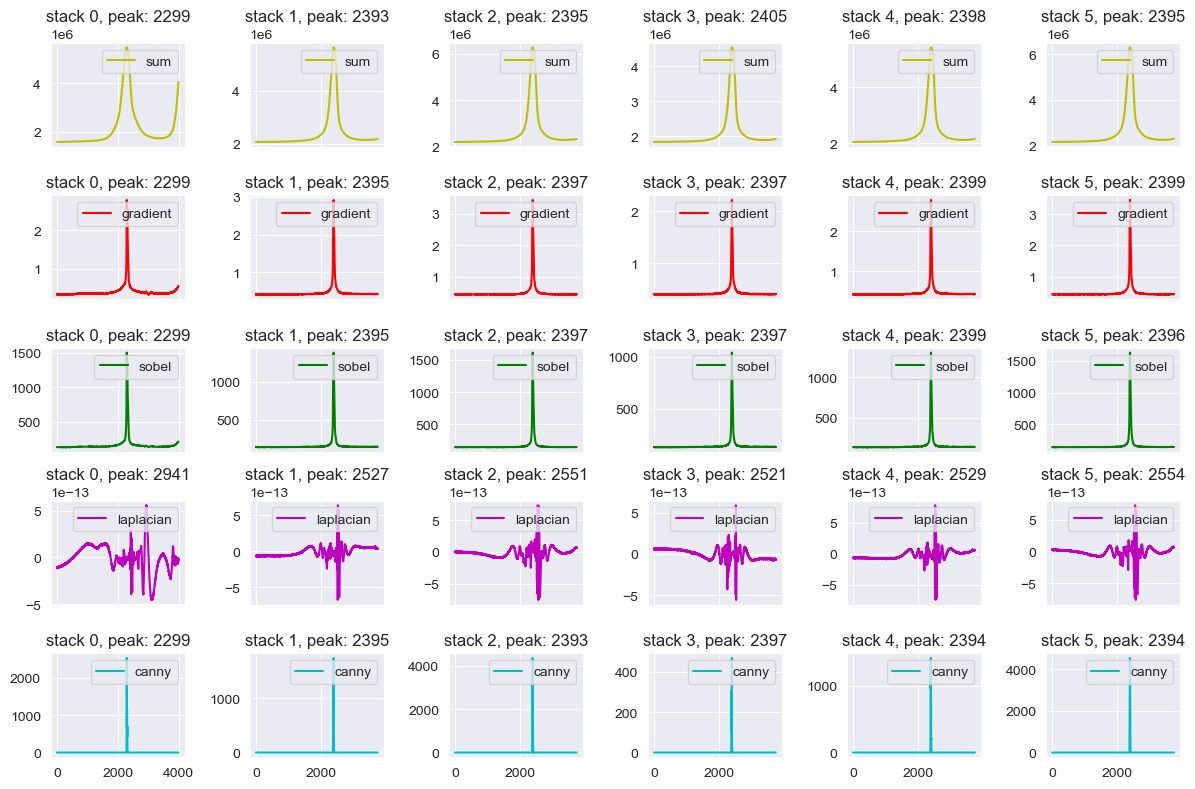

In [22]:
plot_sharpness(stacks_40x)

### stack 0

In [23]:
fig = px.imshow(dataset_40x_0[2299 - GAP : 2299 + GAP], animation_frame=0, binary_string=True)
# plotly.io.show(fig)

In [24]:
torch_40x_0 = ClassificationDataset(dataset_40x_0, focused=2299 + 15, acceptable=5, steps=100)

### stack 1

In [25]:
fig = px.imshow(dataset_40x_1[2395 - GAP : 2395 + GAP], animation_frame=0, binary_string=True)
# plotly.io.show(fig)

In [26]:
torch_40x_1 = ClassificationDataset(dataset_40x_1, focused=2395, acceptable=5, steps=100)

### stack 2

In [27]:
fig = px.imshow(dataset_40x_2[2397 - GAP : 2397 + GAP], animation_frame=0, binary_string=True)
# plotly.io.show(fig)

In [28]:
torch_40x_2 = ClassificationDataset(dataset_40x_2, focused=2397, acceptable=5, steps=100)

### stack 3

In [29]:
fig = px.imshow(dataset_40x_3[2397 - GAP : 2397 + GAP], animation_frame=0, binary_string=True)
# plotly.io.show(fig)

In [30]:
torch_40x_3 = ClassificationDataset(dataset_40x_3, focused=2397, acceptable=5, steps=100)

### stack 4

In [31]:
fig = px.imshow(dataset_40x_4[2398 - GAP : 2398 + GAP], animation_frame=0, binary_string=True)
# plotly.io.show(fig)

In [32]:
torch_40x_4 = ClassificationDataset(dataset_40x_4, focused=2398 + 5, acceptable=5, steps=100)

### stack 5

In [33]:
fig = px.imshow(dataset_40x_5[2396 - GAP : 2396 + GAP], animation_frame=0, binary_string=True)
# plotly.io.show(fig)

In [34]:
torch_40x_5 = ClassificationDataset(dataset_40x_5, focused=2396, acceptable=5, steps=100)

## looking for focused images (60x)

In [35]:
dataset_60x_0 = np.load('data/60x_0.npy')

stacks_60x = [dataset_60x_0]

In [36]:
print(dataset_60x_0.shape)

(5001, 302, 301)


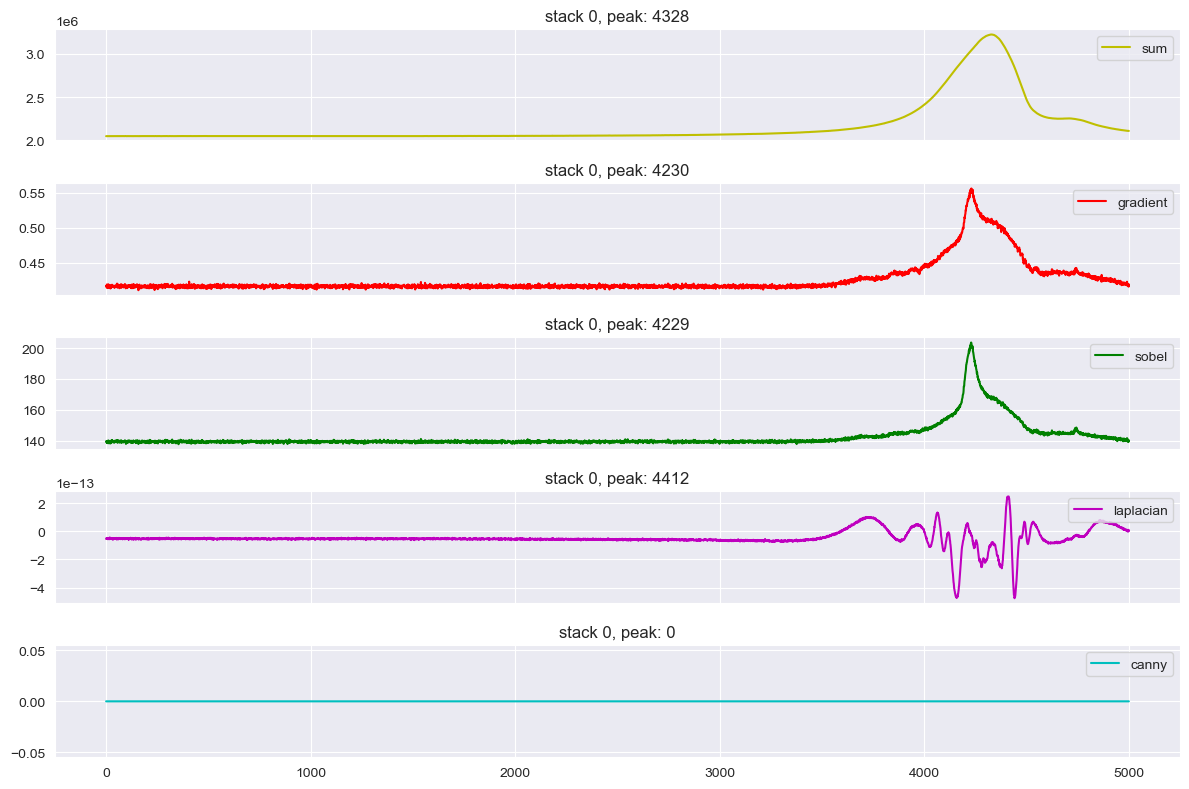

In [37]:
plot_sharpness(stacks_60x)

### stack 0

In [38]:
fig = px.imshow(dataset_60x_0[4230 - GAP : 4230 + GAP], animation_frame=0, binary_string=True)
# plotly.io.show(fig)

In [39]:
torch_60x_0 = ClassificationDataset(dataset_60x_0, focused=4230, acceptable=3, steps=100)

## looking for focused images (100x)

In [40]:
dataset_100x_0 = np.load('data/100x_0.npy')
dataset_100x_1 = np.load('data/100x_1.npy')
dataset_100x_2 = np.load('data/100x_2.npy')

stacks_100x = [dataset_100x_0, dataset_100x_1, dataset_100x_2]

In [41]:
print(dataset_100x_0.shape, dataset_100x_1.shape, dataset_100x_2.shape)

(1751, 301, 301) (1751, 297, 297) (2001, 302, 300)


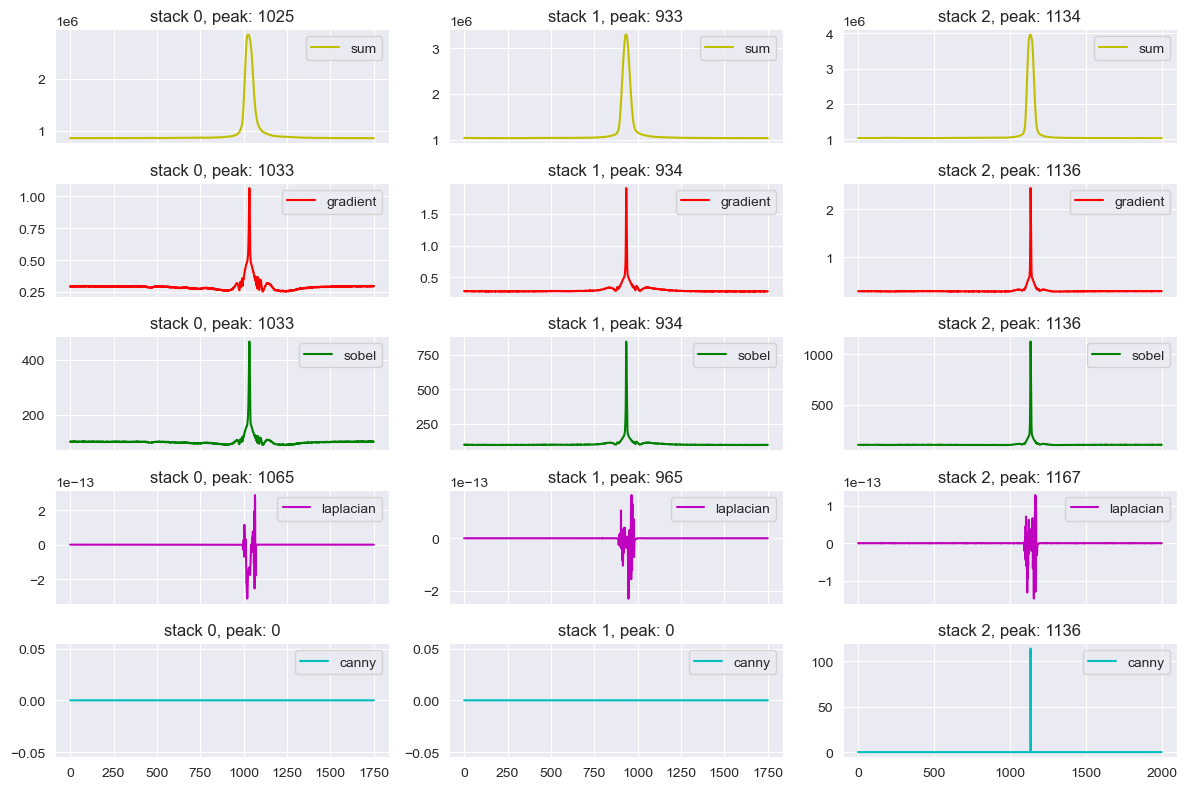

In [42]:
plot_sharpness(stacks_100x)

In [43]:
fig = px.imshow(dataset_100x_0[1033 - GAP : 1033 + GAP], animation_frame=0, binary_string=True)
# plotly.io.show(fig)

In [44]:
torch_100x_0 = ClassificationDataset(dataset_100x_0, focused=1033, acceptable=1, steps=25)

### stack 1

In [45]:
fig = px.imshow(dataset_100x_1[934 - GAP : 934 + GAP], animation_frame=0, binary_string=True)
# plotly.io.show(fig)

In [46]:
torch_100x_1 = ClassificationDataset(dataset_100x_1, focused=934, acceptable=1, steps=25)

### stack 2

In [47]:
fig = px.imshow(dataset_100x_2[1134 - GAP : 1134 + GAP], animation_frame=0, binary_string=True)
# plotly.io.show(fig)

In [48]:
torch_100x_2 = ClassificationDataset(dataset_100x_2, focused=1134 + 2, acceptable=1, steps=25)

# Dataset creation

Here, we create three classification datasets, as defined in the paper: $all13-r-45, 10x-r-10$, and $20x-r-5$

Then, we save them to files

In [49]:
all13 = ConcatDataset([torch_10x_0, torch_10x_1,
                       torch_20x_0,
                       torch_40x_0, torch_40x_1, torch_40x_2, torch_40x_3, torch_40x_4, torch_40x_5,
                       torch_60x_0,
                       torch_100x_0, torch_100x_1, torch_100x_2])

In [50]:
# helper.create_dataset(all13, "all13-r-45-clf")

In [51]:
torch_10x_0 = ClassificationDataset(dataset_10x_0, focused=2013, acceptable=7, steps=100, angle=10)
torch_10x_1 = ClassificationDataset(dataset_10x_1, focused=2072, acceptable=7, steps=100, angle=10)

torch_10x = ConcatDataset([torch_10x_0, torch_10x_1,])

# helper.create_dataset(torch_10x, name='10x-r-10')

In [52]:
torch_20x_0 = ClassificationDataset(dataset_20x_0, focused=2465, acceptable=5, steps=100, angle=5)


# helper.create_dataset(torch_20x_0, name='20x-r-5')